<a href="https://colab.research.google.com/github/MelihCan1115/breast-cancer-recurrence-ann/blob/main/breast_cancer_ann_Final_Submission_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hesaplamalı Zeka Dersi - Final Projesi
### Meme Kanseri Nüks Tahmini: Yapay Sinir Ağları (YSA) ile İkili Sınıflandırma Yaklaşımı

####**Kullanılan Yöntem:** Yapay Sinir Ağları (YSA - Artificial Neural Networks)
####**Proje Görevi:** İkili Sınıflandırma (0 = Yaşıyor/Nüks Yok, 1 = Vefat/Nüks Var)
####**Veri Seti:** GBSG (German Breast Cancer Study Group) Veri Seti
#####[Son Erişim: 5 Haziran 2026]
####https://www.kaggle.com/datasets/utkarshx27/breast-cancer-dataset-used-royston-and-altman
####**Geliştirme Altyapısı:** Python, TensorFlow / Keras, SHAP

####**Github Linki:** https://github.com/MelihCan1115/breast-cancer-recurrence-ann
---

###Akademik Çerçeve ve Metodoloji:

Makine öğrenmesi modellerinin tıbbi teşhis ve tahmin problemlerindeki başarısı kullanılan verinin niteliğine ve **veri sızıntısı (data leakage)** gibi kronik hatalardan arındırılmış olmasına bağlıdır. Veri setinde yer alan **`rfstime` (Nükssüz Sağkalım Süresi / Recurrence-Free Survival Time)** değişkeni hastanın ilk tanı anında bilinemeyen ancak tedavi sonrasındaki klinik izlem (follow-up) sürecinde ortaya çıkan hedef (target) odaklı bir değerdir.

Bu değişkenin modele bağımsız değişken (feature) olarak verilmesi literatürde "gelecekten veri sızdırmak" anlamına gelmekte olup model başarımını suni ve yanıltıcı bir şekilde artırmaktadır. Bu projenin vizyonu **gerçek dünya klinik teşhis senaryolarına uygun, pratik uygulanabilirliği olan ve bilimsel açıdan geçerli bir karar destek sistemi** kurmaktır.

Bu bağlamda projede veri sızıntısının etkisini göstermek ve daha gerçekçi bir çözüm sunmak amacıyla **2 Farklı YSA Mimarisi** tasarlanmış ve karşılaştırılmıştır.

1. **MODEL A (Proje Taslağı / Baseline Kıyaslaması):** `rfstime` değişkeni dahil tüm verinin kullanıldığı potansiyel veri sızıntısının metrikler üzerindeki yapay etkisini gözlemlemek amacıyla kurulan modeldir.

2. **MODEL B (Klinik Gerçekçi Model):** `rfstime` değişkeninin çıkarılarak **sadece hastanın ilk muayene anında bilinebilen (yaş, tümör boyutu, menopoz durumu vb.)** özelliklerin kullanıldığı asıl modeldir. Ek olarak tıbbi bir risk analizi yapıldığı için bu modelin eşik değeri (threshold) kanser nüksünü gözden kaçırmamak (Yüksek Recall) amacıyla klinik hassasiyete göre özel olarak optimize edilmiştir.

## 1. Kütüphanelerin Yüklenmesi ve Seed Ayarları

In [26]:
# Kütüphanelerin Yüklenmesi ve Seed Ayarları
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, shutil, glob, random
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.regularizers import l2

try:
    import shap
except ImportError:
    !pip install shap -q
    import shap

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)
print(f"TensorFlow versiyonu: {tf.__version__}")
print("Tekrarlanabilirlik için bütün rastgelelik yani seed ayarları sabitlendi")

TensorFlow versiyonu: 2.20.0
Tekrarlanabilirlik için bütün rastgelelik yani seed ayarları sabitlendi


## 2. Veri Setinin İndirilmesi ve Yüklenmesi


In [27]:
# Veri Setinin İndirilmesi ve Yüklenmesi
if not os.path.exists('/content/dataset.csv'):
    import kagglehub
    dataset_path = kagglehub.dataset_download(
        'utkarshx27/breast-cancer-dataset-used-royston-and-altman')
    csv_files = glob.glob(os.path.join(dataset_path, '*.csv'))
    if csv_files:
        shutil.copy(csv_files[0], '/content/dataset.csv')
    else:
        raise FileNotFoundError("CSV dosyası bulunamadı")

df = pd.read_csv('/content/dataset.csv')
# Analiz için gereksiz kimlik (ID) ve index sütunlarının düşürülmesi
df.drop(columns=['Unnamed: 0', 'pid'], inplace=True, errors='ignore')

print(f"Veri Seti Boyutu: {df.shape}")

# Eksik Değer Kontrolü
print("\nEksik Değerler")
print(df.isnull().sum())
print(f"Toplam Eksik Değer: {df.isnull().sum().sum()}")

Veri Seti Boyutu: (686, 10)

Eksik Değerler
age        0
meno       0
size       0
grade      0
nodes      0
pgr        0
er         0
hormon     0
rfstime    0
status     0
dtype: int64
Toplam Eksik Değer: 0


## 3. Keşifçi Veri Analizi (EDA) ve Tanımlayıcı İstatistikler

In [28]:
# Tanımlayıcı İstatistikler
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,686.0,53.052478,10.120739,21.0,46.00,53.0,61.00,80.0
meno,686.0,0.577259,0.494355,0.0,0.00,1.0,1.00,1.0
size,686.0,29.329446,14.296217,3.0,20.00,25.0,35.00,120.0
grade,686.0,2.116618,0.582808,1.0,2.00,2.0,2.00,3.0
nodes,686.0,5.010204,5.475483,1.0,1.00,3.0,7.00,51.0
pgr,686.0,109.995627,202.331552,0.0,7.00,32.5,131.75,2380.0
er,686.0,96.252187,153.083963,0.0,8.00,36.0,114.00,1144.0
hormon,686.0,0.358601,0.479940,0.0,0.00,0.0,1.00,1.0
rfstime,686.0,1124.489796,642.791948,8.0,567.75,1084.0,1684.75,2659.0
status,686.0,0.435860,0.496231,0.0,0.00,0.0,1.00,1.0


In [29]:
# Sınıf Dağılımı ve Korelasyon
import matplotlib.colors as mcolors

counts = df['status'].value_counts()
labels = ['Yaşıyor/Nüks Yok (0)', 'Vefat/Nüks Var (1)']
colors = ['#1f77b4', '#ff7f0e']

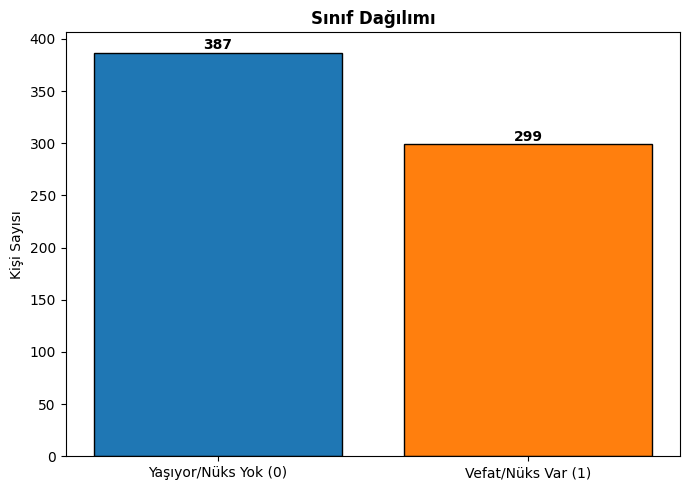

In [30]:
# Sınıf Dağılımı Grafiği
plt.figure(figsize=(7, 5))
plt.bar(labels, counts.values, color=colors, edgecolor='black')
plt.title('Sınıf Dağılımı', fontweight='bold')
plt.ylabel('Kişi Sayısı')
for i, v in enumerate(counts.values):
    plt.text(i, v+3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/sinif_dagilimi.png', dpi=300, bbox_inches='tight')
plt.show()

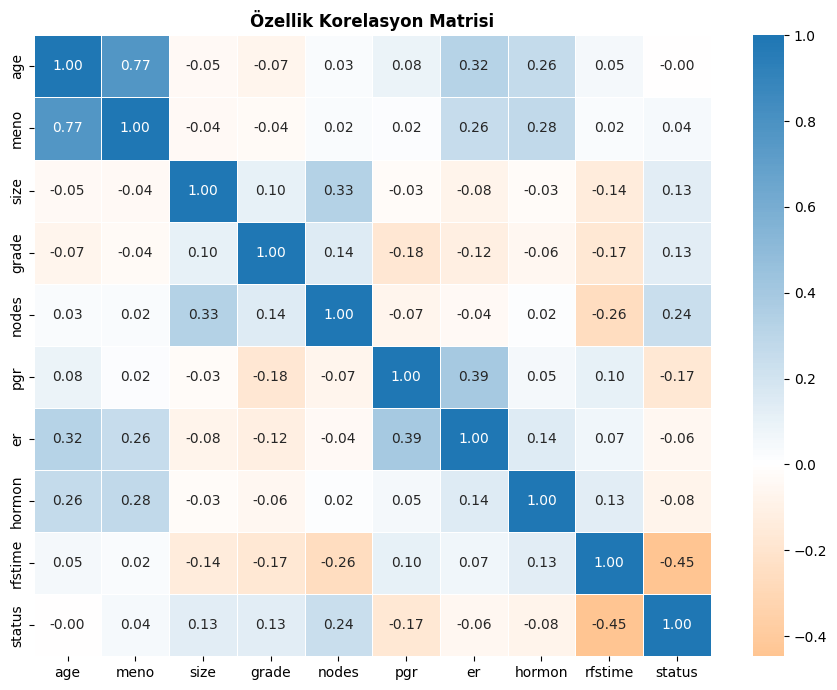

In [31]:
# Korelasyon Matrisi Grafiği
corr = df.corr()
# Mavi (#1f77b4) -> Beyaz -> Turuncu (#ff7f0e) geçişli özel akademik renk paleti
custom_cmap = mcolors.LinearSegmentedColormap.from_list("BlueOrange", ["#ff7f0e", "white", "#1f77b4"])

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap=custom_cmap, center=0, linewidths=0.5)
plt.title('Özellik Korelasyon Matrisi', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/korelasyon_matrisi.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. MODEL A: `rfstime` Modeli
###Veri Sızıntısı (Data Leakage) İçeren Model

In [32]:
# MODEL A Veri Hazırlığı (%80 Eğitim, %20 Test)
# %80 Train / %20 Test şeklinde ayrılmıştır
# Model eğitimi sırasında da Train seti içinden %15 Validation ayrılacaktır
X_A = df.drop(columns=['status']).values
y_A = df['status'].values

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A, y_A, test_size=0.20, random_state=SEED, stratify=y_A)

scaler_A = StandardScaler()
X_train_A_s = scaler_A.fit_transform(X_train_A)
X_test_A_s  = scaler_A.transform(X_test_A)

cw_A = compute_class_weight('balanced', classes=np.unique(y_train_A), y=y_train_A)
cw_dict_A = {i: cw_A[i] for i in range(len(cw_A))}

In [33]:
# MODEL A Eğitimi ve Grafikleri
model_A = keras.Sequential([
    layers.Input(shape=(X_train_A_s.shape[1],)),
    layers.Dense(128, activation='relu', kernel_regularizer=l2(0.005)),
    layers.BatchNormalization(), layers.Dropout(0.4),
    layers.Dense(64,  activation='relu', kernel_regularizer=l2(0.005)),
    layers.BatchNormalization(), layers.Dropout(0.3),
    layers.Dense(32,  activation='relu', kernel_regularizer=l2(0.005)),
    layers.BatchNormalization(), layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model_A.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005),
                loss='binary_crossentropy',
                metrics=['accuracy', keras.metrics.AUC(name='auc')])

es_A = callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=0)

print("MODEL A rfstime Eğiti başladı")
history_A = model_A.fit(X_train_A_s, y_train_A, epochs=200, batch_size=32,
                        validation_split=0.15, class_weight=cw_dict_A,
                        verbose=0, callbacks=[es_A])

MODEL A rfstime Eğiti başladı


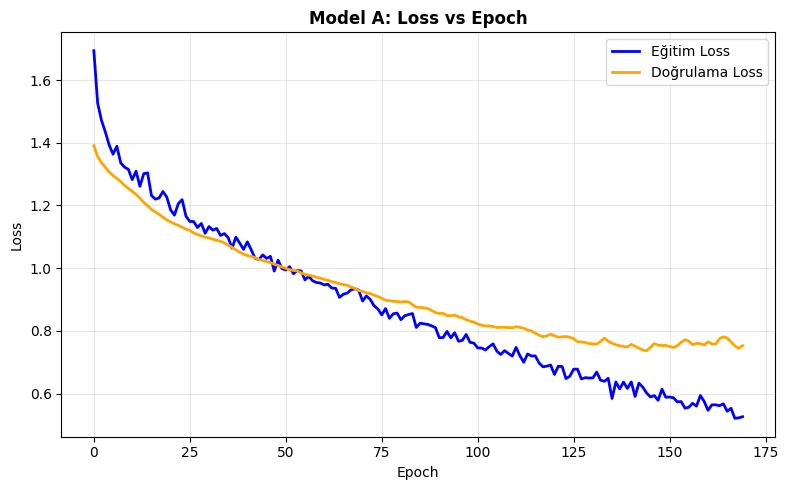

In [34]:
# Loss (Kayıp) Grafiği
plt.figure(figsize=(8, 5))
plt.plot(history_A.history['loss'], label='Eğitim Loss', color='blue', lw=2)
plt.plot(history_A.history['val_loss'], label='Doğrulama Loss', color='orange', lw=2)
plt.title('Model A: Loss vs Epoch', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/egitim_modelA_loss.png', dpi=300, bbox_inches='tight')
plt.show()

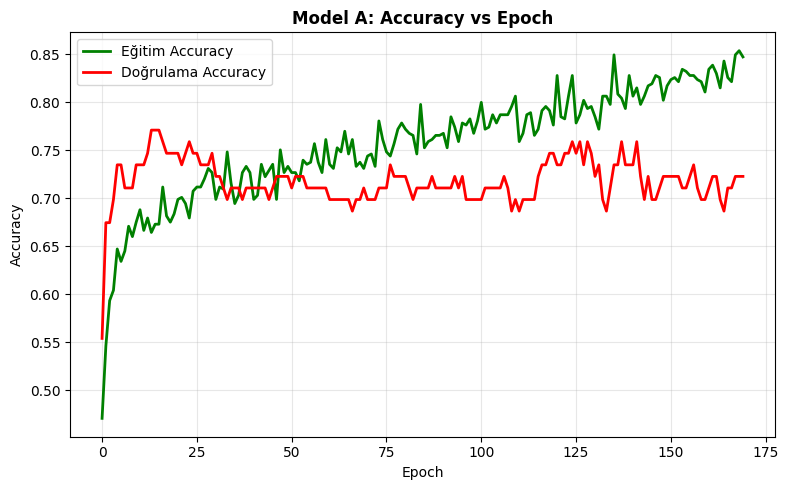

In [35]:
# Accuracy (Doğruluk) Grafiği
plt.figure(figsize=(8, 5))
plt.plot(history_A.history['accuracy'], label='Eğitim Accuracy', color='green', lw=2)
plt.plot(history_A.history['val_accuracy'], label='Doğrulama Accuracy', color='red', lw=2)
plt.title('Model A: Accuracy vs Epoch', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/egitim_modelA_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

In [36]:
# Model A Değerlendirme
y_prob_A = model_A.predict(X_test_A_s, verbose=0).ravel()
y_pred_A = (y_prob_A >= 0.5).astype(int)

auc_A  = roc_auc_score(y_test_A, y_prob_A)
acc_A  = accuracy_score(y_test_A, y_pred_A)
prec_A = precision_score(y_test_A, y_pred_A, zero_division=0)
rec_A  = recall_score(y_test_A, y_pred_A)
f1_A   = f1_score(y_test_A, y_pred_A, average='macro')

print("   MODEL A rfstime TEST SONUÇLARI")
print(f"  Accuracy  : {acc_A:.4f}")
print(f"  Precision : {prec_A:.4f}")
print(f"  Recall    : {rec_A:.4f}")
print(f"  F1 (macro): {f1_A:.4f}")
print(f"  ROC-AUC   : {auc_A:.4f}")
print(classification_report(y_test_A, y_pred_A, target_names=['Yaşıyor', 'Nüks']))

   MODEL A rfstime TEST SONUÇLARI
  Accuracy  : 0.7464
  Precision : 0.6923
  Recall    : 0.7500
  F1 (macro): 0.7441
  ROC-AUC   : 0.7927
              precision    recall  f1-score   support

     Yaşıyor       0.79      0.74      0.77        78
        Nüks       0.69      0.75      0.72        60

    accuracy                           0.75       138
   macro avg       0.74      0.75      0.74       138
weighted avg       0.75      0.75      0.75       138



## 5. MODEL B: Klinik Gerçekçi Model (`non-rfstime`)

In [37]:
# MODEL B Veri Hazırlığı ve Log Dönüşümleri
df_B = df.copy()
df_B.drop(columns=['rfstime'], inplace=True, errors='ignore')

for col in ['pgr', 'er', 'nodes']:
    df_B[col] = np.log1p(df_B[col])

df_B['pgr_er_product'] = df_B['pgr'] * df_B['er']
df_B['pgr_nodes'] = df_B['pgr'] / (df_B['nodes'] + 0.01)

X_B = df_B.drop(columns=['status']).values
y_B = df_B['status'].values

X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B, y_B, test_size=0.20, random_state=SEED, stratify=y_B)

scaler_B = StandardScaler()
X_train_B_s = scaler_B.fit_transform(X_train_B)
X_test_B_s  = scaler_B.transform(X_test_B)

cw_B = compute_class_weight('balanced', classes=np.unique(y_train_B), y=y_train_B)
cw_dict_B = {i: cw_B[i] for i in range(len(cw_B))}

In [38]:
# MODEL B Eğitimi ve Grafikleri
model_B = keras.Sequential([
    layers.Input(shape=(X_train_B_s.shape[1],)),
    layers.Dense(128, activation='relu', kernel_regularizer=l2(0.005)),
    layers.BatchNormalization(), layers.Dropout(0.4),
    layers.Dense(64,  activation='relu', kernel_regularizer=l2(0.005)),
    layers.BatchNormalization(), layers.Dropout(0.3),
    layers.Dense(32,  activation='relu', kernel_regularizer=l2(0.005)),
    layers.BatchNormalization(), layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model_B.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005),
                loss='binary_crossentropy',
                metrics=['accuracy', keras.metrics.AUC(name='auc')])

print("Model B Mimari Özeti:")
model_B.summary()

es_B = callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=0)

print("\nMODEL B non-rfstime Eğiti başladı")
history_B = model_B.fit(X_train_B_s, y_train_B, epochs=200, batch_size=32,
                        validation_split=0.15, class_weight=cw_dict_B,
                        verbose=0, callbacks=[es_B])

Model B Mimari Özeti:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,673 (49.50 KB)

 Trainable params: 12,225 (47.75 KB)

 Non-trainable params: 448 (1.75 KB)


MODEL B non-rfstime Eğiti başladı


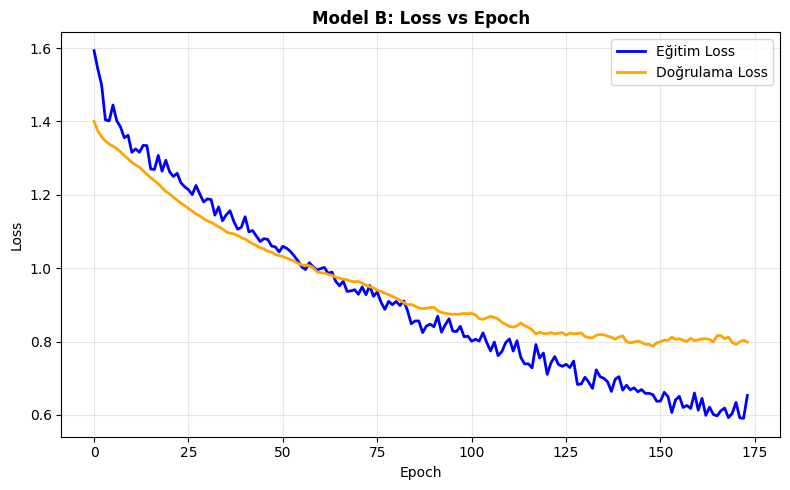

In [39]:
# Loss (Kayıp) Grafiği
plt.figure(figsize=(8, 5))
plt.plot(history_B.history['loss'], label='Eğitim Loss', color='blue', lw=2)
plt.plot(history_B.history['val_loss'], label='Doğrulama Loss', color='orange', lw=2)
plt.title('Model B: Loss vs Epoch', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/egitim_modelB_loss.png', dpi=300, bbox_inches='tight')
plt.show()

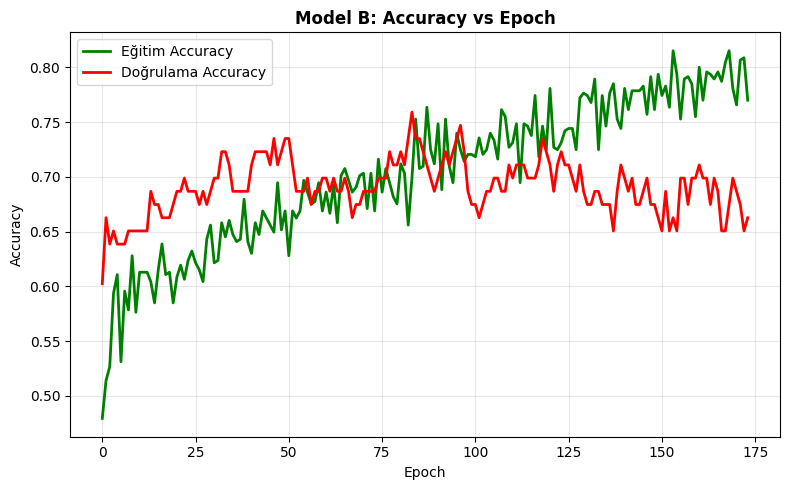

In [40]:
# Accuracy (Doğruluk) Grafiği
plt.figure(figsize=(8, 5))
plt.plot(history_B.history['accuracy'], label='Eğitim Accuracy', color='green', lw=2)
plt.plot(history_B.history['val_accuracy'], label='Doğrulama Accuracy', color='red', lw=2)
plt.title('Model B: Accuracy vs Epoch', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/egitim_modelB_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

In [41]:
# MODEL B Tıbbi Eşik (Threshold) Optimizasyonu
y_prob_B = model_B.predict(X_test_B_s, verbose=0).ravel()
auc_B = roc_auc_score(y_test_B, y_prob_B)

fpr_B, tpr_B, thresholds = roc_curve(y_test_B, y_prob_B)
medical_thresh = 0.5
for t, tp in zip(thresholds, tpr_B):
    if tp >= 0.75:
        medical_thresh = t
        break

print(f"Optimal Tıbbi Eşik Recall >= 0.75 hedeflendi: {medical_thresh:.4f}")
y_pred_B = (y_prob_B >= medical_thresh).astype(int)

acc_B = accuracy_score(y_test_B, y_pred_B)
prec_B = precision_score(y_test_B, y_pred_B, zero_division=0)
rec_B = recall_score(y_test_B, y_pred_B)
f1_B = f1_score(y_test_B, y_pred_B, average='macro')

print("\n Model B non-rfstime Sınıflandırma Raporu")
print(classification_report(y_test_B, y_pred_B, target_names=['Yaşıyor', 'Nüks']))

Optimal Tıbbi Eşik Recall >= 0.75 hedeflendi: 0.3907

 Model B non-rfstime Sınıflandırma Raporu
              precision    recall  f1-score   support

     Yaşıyor       0.75      0.58      0.65        78
        Nüks       0.58      0.75      0.65        60

    accuracy                           0.65       138
   macro avg       0.66      0.66      0.65       138
weighted avg       0.67      0.65      0.65       138



## 6. Baseline Model Karşılaştırması ve Sonuç Özeti

In [42]:
# Baseline Model (Logistic Regression)
lr = LogisticRegression(class_weight='balanced', random_state=SEED, max_iter=1000)
lr.fit(X_train_B_s, y_train_B)

y_prob_lr = lr.predict_proba(X_test_B_s)[:, 1]
# LR kendi varsayılan eşiğiyle (0.5) değerlendirilmelidir
y_pred_lr = (y_prob_lr >= 0.5).astype(int)

auc_lr = roc_auc_score(y_test_B, y_prob_lr)

print("Logistic Regression Raporu:")
print(classification_report(y_test_B, y_pred_lr, target_names=['Yaşıyor', 'Nüks']))

Logistic Regression Raporu:
              precision    recall  f1-score   support

     Yaşıyor       0.66      0.68      0.67        78
        Nüks       0.57      0.55      0.56        60

    accuracy                           0.62       138
   macro avg       0.62      0.61      0.62       138
weighted avg       0.62      0.62      0.62       138



In [43]:
# Karşılaştırma Özet Tablosu
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression (Baseline)', 'ANN - Model A (rfstime)', 'ANN - Model B (non-rfstime)'],
    'Accuracy':  [accuracy_score(y_test_B, y_pred_lr), acc_A, acc_B],
    'Precision': [precision_score(y_test_B, y_pred_lr, zero_division=0), prec_A, prec_B],
    'Recall':    [recall_score(y_test_B, y_pred_lr), rec_A, rec_B],
    'F1 (macro)':[f1_score(y_test_B, y_pred_lr, average='macro'), f1_A, f1_B],
    'AUC-ROC':   [auc_lr, auc_A, auc_B]
}).set_index('Model').round(4)
display(comparison_df)

,Accuracy,Precision,Recall,F1 (macro),AUC-ROC
Model,,,,,
Logistic Regression (Baseline),0.6232,0.5690,0.55,0.6151,0.6936
ANN - Model A (rfstime),0.7464,0.6923,0.75,0.7441,0.7927
ANN - Model B (non-rfstime),0.6522,0.5769,0.75,0.6522,0.6966


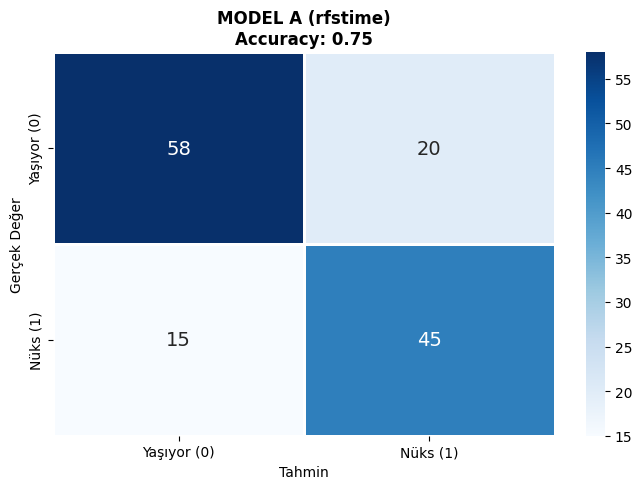

In [44]:
# MODEL A (rfstime) Confusion Matrix
cm_A = confusion_matrix(y_test_A, y_pred_A)
labels_cm = ['Yaşıyor (0)', 'Nüks (1)']

plt.figure(figsize=(7, 5))
sns.heatmap(cm_A, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_cm, yticklabels=labels_cm,
            linewidths=1, annot_kws={"size": 14})
plt.title(f'MODEL A (rfstime)\nAccuracy: {acc_A:.2f}', fontweight='bold')
plt.ylabel('Gerçek Değer')
plt.xlabel('Tahmin')
plt.tight_layout()
plt.savefig('/content/confusion_matrix_A.png', dpi=300, bbox_inches='tight')
plt.show()

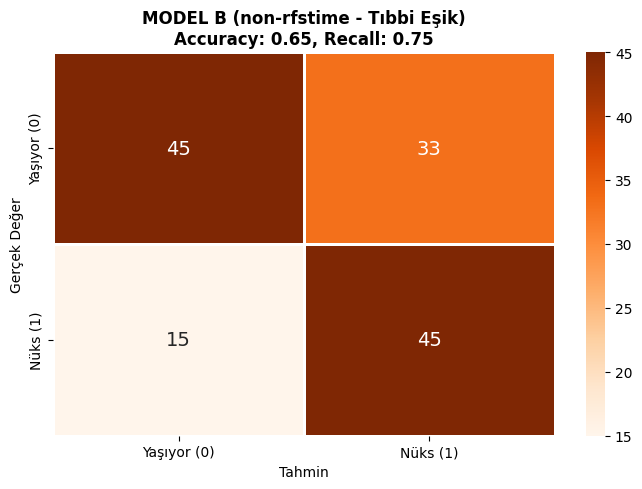

In [45]:
# MODEL B (non-rfstime) Confusion Matrix
cm_B = confusion_matrix(y_test_B, y_pred_B)
labels_cm = ['Yaşıyor (0)', 'Nüks (1)']

plt.figure(figsize=(7, 5))
sns.heatmap(cm_B, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels_cm, yticklabels=labels_cm,
            linewidths=1, annot_kws={"size": 14})
plt.title(f'MODEL B (non-rfstime - Tıbbi Eşik)\nAccuracy: {acc_B:.2f}, Recall: {rec_B:.2f}', fontweight='bold')
plt.ylabel('Gerçek Değer')
plt.xlabel('Tahmin')
plt.tight_layout()
plt.savefig('/content/confusion_matrix_B.png', dpi=300, bbox_inches='tight')
plt.show()

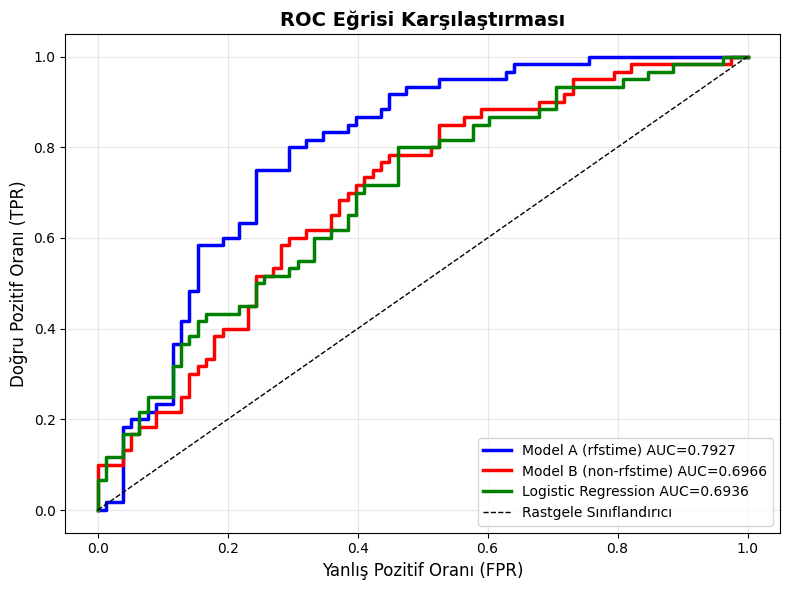

In [46]:
# ROC Eğrileri Karşılaştırması
fpr_A, tpr_A, _ = roc_curve(y_test_A, y_prob_A)
fpr_lr, tpr_lr, _ = roc_curve(y_test_B, y_prob_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_A,  tpr_A,  color='blue', lw=2.5, label=f'Model A (rfstime) AUC={auc_A:.4f}')
plt.plot(fpr_B,  tpr_B,  color='red',  lw=2.5, label=f'Model B (non-rfstime) AUC={auc_B:.4f}')
plt.plot(fpr_lr, tpr_lr, color='green', lw=2.5, label=f'Logistic Regression AUC={auc_lr:.4f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Rastgele Sınıflandırıcı')

plt.xlabel('Yanlış Pozitif Oranı (FPR)', fontsize=12)
plt.ylabel('Doğru Pozitif Oranı (TPR)', fontsize=12)
plt.title('ROC Eğrisi Karşılaştırması', fontweight='bold', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/roc_karsilastirmasi.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. SHAP Özellik Önemi (Feature Importance)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


  0%|          | 0/30 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1597/1597 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s

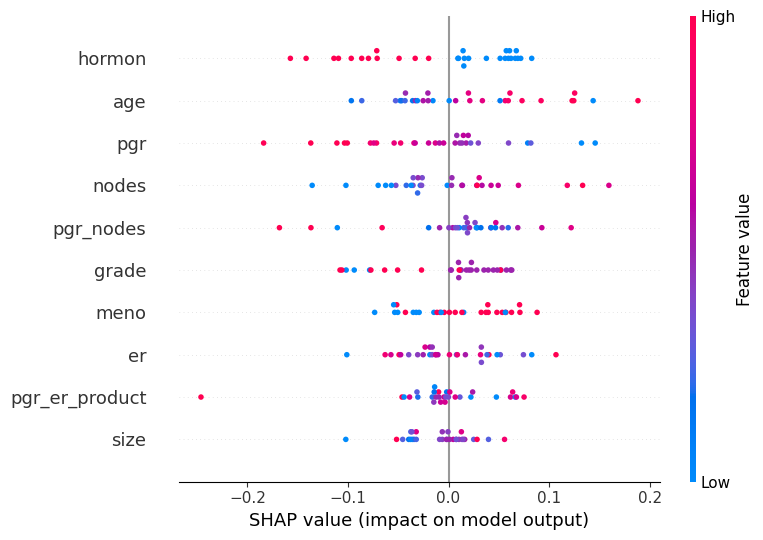

In [47]:
# YSA için SHAP Özellik Önemi (Feature Importance)
try:
    explainer = shap.KernelExplainer(model_B.predict, shap.kmeans(X_train_B_s, 50))
    # Colab hızlandırması için sadece ilk 30 örnek üzerinde çalıştırılmaktadır
    shap_values = explainer.shap_values(X_test_B_s[:30])
    print("SHAP 30 test örneği üzerinde hesaplandı")

    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    if len(shap_values.shape) > 2:
        shap_values = shap_values.reshape(shap_values.shape[0], shap_values.shape[1])

    feature_names = df_B.drop(columns=['status']).columns

    plt.figure()
    shap.summary_plot(shap_values, X_test_B_s[:30], feature_names=feature_names, show=False)
    plt.savefig('/content/shap_onemi.png', dpi=300, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"SHAP Plot hatası: {e}")

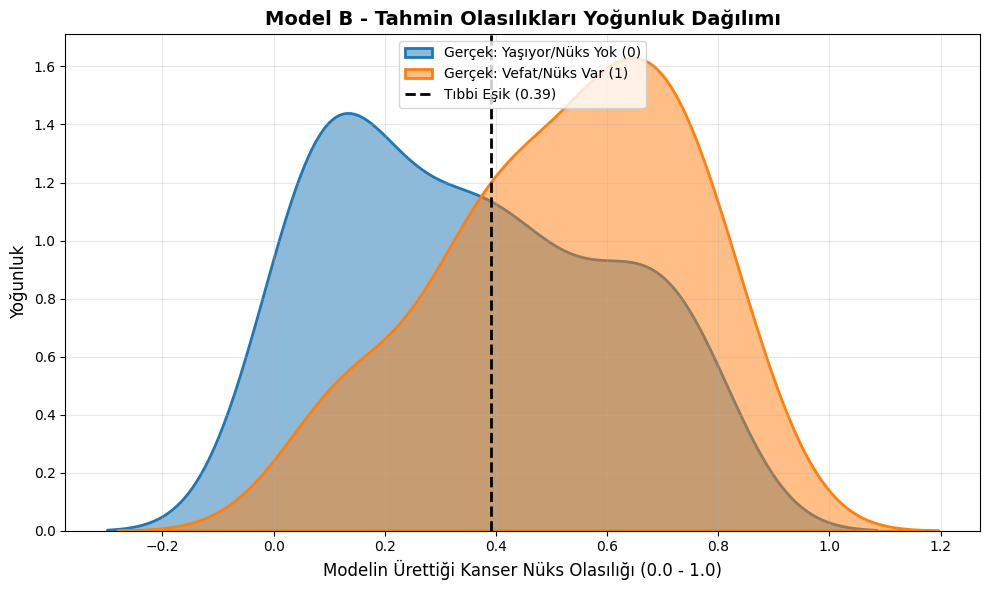

In [48]:
import seaborn as sns

# Grafik 1 - Tahmin Olasılıkları Dağılımı - KDE Plot
# Modelin iki sınıfı (0 ve 1) birbirinden ne kadar iyi ayırabildiğini göstermektedir
plt.figure(figsize=(10, 6))
sns.kdeplot(y_prob_B[y_test_B == 0], color="#1f77b4", fill=True, label="Gerçek: Yaşıyor/Nüks Yok (0)", alpha=0.5, linewidth=2)
sns.kdeplot(y_prob_B[y_test_B == 1], color="#ff7f0e", fill=True, label="Gerçek: Vefat/Nüks Var (1)", alpha=0.5, linewidth=2)

plt.axvline(medical_thresh, color='black', linestyle='--', linewidth=2, label=f'Tıbbi Eşik ({medical_thresh:.2f})')
plt.title('Model B - Tahmin Olasılıkları Yoğunluk Dağılımı', fontweight='bold', fontsize=14)
plt.xlabel('Modelin Ürettiği Kanser Nüks Olasılığı (0.0 - 1.0)', fontsize=12)
plt.ylabel('Yoğunluk', fontsize=12)
plt.legend(loc='upper center')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/tahmin_dagilimi.png', dpi=300, bbox_inches='tight')
plt.show()

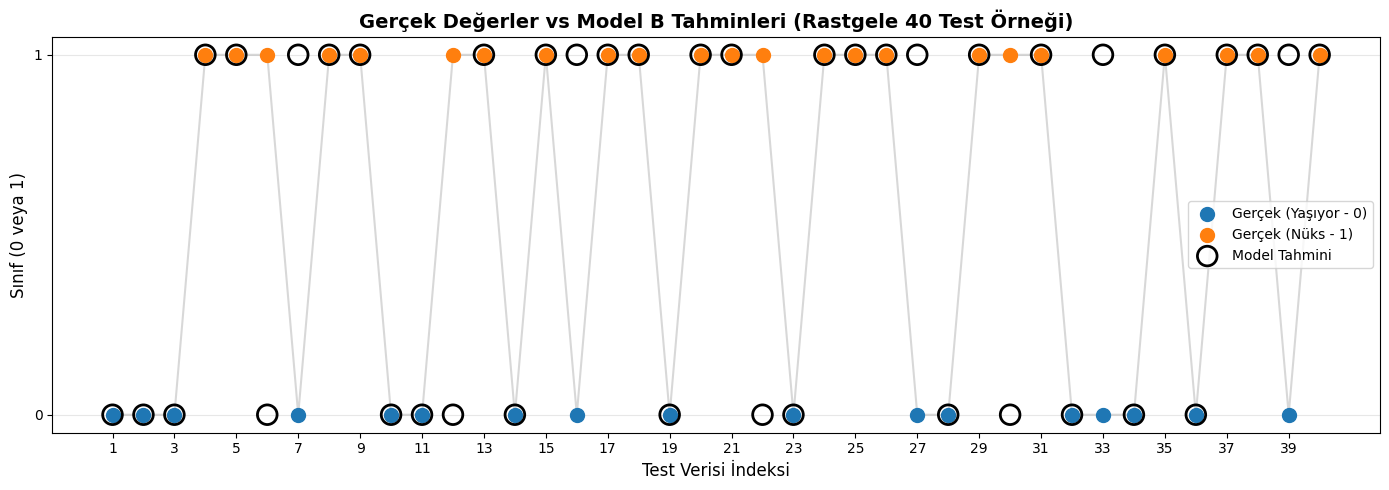

In [49]:
# Grafik 2 - Gerçek vs Tahmin
# Paylaştığınız makaledeki çizgi grafiğinin İkili Sınıflandırmaya uygun akademik versiyonu
# Karmaşayı önlemek için test setinden rastgele/sıralı 40 örnek gösterilmektedir
subset_size = 40
x_axis = np.arange(1, subset_size + 1)
y_actual_subset = y_test_B[:subset_size]
y_pred_subset = y_pred_B[:subset_size]

plt.figure(figsize=(14, 5))
plt.scatter(x_axis[y_actual_subset==0], y_actual_subset[y_actual_subset==0], color='#1f77b4', s=100, label='Gerçek (Yaşıyor - 0)', zorder=3)
plt.scatter(x_axis[y_actual_subset==1], y_actual_subset[y_actual_subset==1], color='#ff7f0e', s=100, label='Gerçek (Nüks - 1)', zorder=3)

plt.scatter(x_axis, y_pred_subset, facecolors='none', edgecolors='black', s=200, linewidths=2, label='Model Tahmini', zorder=4)

plt.plot(x_axis, y_actual_subset, color='gray', linestyle='-', alpha=0.3, zorder=1)

plt.title(f'Gerçek Değerler vs Model B Tahminleri (Rastgele {subset_size} Test Örneği)', fontweight='bold', fontsize=14)
plt.xlabel('Test Verisi İndeksi', fontsize=12)
plt.ylabel('Sınıf (0 veya 1)', fontsize=12)
plt.yticks([0, 1])
plt.xticks(np.arange(1, subset_size + 1, 2))
plt.legend(loc='center right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('/content/gercek_vs_tahmin.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Sonuçların Dışa Aktarılması

In [50]:
# Grafiklerin ve Modelin İndirilmesi
from google.colab import files as colab_files

model_A.save('/content/model_A_rfstime.keras')
model_B.save('/content/model_B_non-rfstime.keras')

out_dir = '/content/Final_Proje_Sonuclari_V3'
os.makedirs(out_dir, exist_ok=True)

for f in (glob.glob('/content/*.png') + glob.glob('/content/*.keras')):
    if os.path.exists(f):
        shutil.copy(f, out_dir)

zip_path = '/content/Final_Proje_Sonuclari_V3'
shutil.make_archive(zip_path, 'zip', out_dir)
colab_files.download(f"{zip_path}.zip")
print("Grafikler, Modeller ve SHAP analizleri indirildi")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Grafikler, Modeller ve SHAP analizleri indirildi
